In [1]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import distill.taskflow as taskflow
from pathlib import Path
from distill.configuration_file import config

c:\Users\polur\miniconda3\envs\geoloc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
opt=config(r"distill/config_with_attention_head.json")

In [8]:
from distill.taskflow import *

In [9]:
import torch

In [10]:
model = taskflow.FPI(opt, device="cpu")

In [11]:
ckpt = torch.load(r"D:\CrossGeoLoc_clear_version\for_us\checkpoints\net_best.pth", map_location="cpu")

In [15]:
model_keys = set(model.state_dict().keys())
ckpt = torch.load(r"D:\CrossGeoLoc_clear_version\for_us\checkpoints\net_best.pth", map_location="cpu")
new_state_dict = {}
for k, v in ckpt.items():
    # вариант без префикса
    if k in model_keys:
        new_state_dict[k] = v
    # вариант с префиксом
    elif "backbone_uav.backbone." + k in model_keys:
        new_state_dict["backbone_uav.backbone." + k] = v
    else:
        print("SKIP:", k)

missing, unexpected = model.load_state_dict(new_state_dict, strict=True)

print("missing:", missing)
print("unexpected:", unexpected)

missing: []
unexpected: []


In [16]:
print(list(ckpt.keys())[:10])
print(list(model.state_dict().keys())[:10])

['backbone_uav.backbone.cls_token', 'backbone_uav.backbone.pos_embed', 'backbone_uav.backbone.patch_embed.proj.weight', 'backbone_uav.backbone.patch_embed.proj.bias', 'backbone_uav.backbone.blocks.0.norm1.weight', 'backbone_uav.backbone.blocks.0.norm1.bias', 'backbone_uav.backbone.blocks.0.attn.qkv.weight', 'backbone_uav.backbone.blocks.0.attn.qkv.bias', 'backbone_uav.backbone.blocks.0.attn.proj.weight', 'backbone_uav.backbone.blocks.0.attn.proj.bias']
['backbone_uav.backbone.cls_token', 'backbone_uav.backbone.pos_embed', 'backbone_uav.backbone.patch_embed.proj.weight', 'backbone_uav.backbone.patch_embed.proj.bias', 'backbone_uav.backbone.blocks.0.norm1.weight', 'backbone_uav.backbone.blocks.0.norm1.bias', 'backbone_uav.backbone.blocks.0.attn.qkv.weight', 'backbone_uav.backbone.blocks.0.attn.qkv.bias', 'backbone_uav.backbone.blocks.0.attn.proj.weight', 'backbone_uav.backbone.blocks.0.attn.proj.bias']


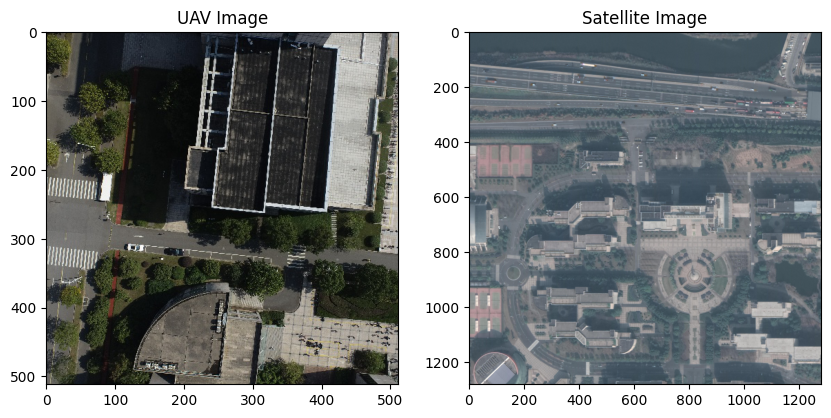

In [82]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'map2019\train\Caijing_000009\UAV\0.JPG'  # Example path
satellite_image_path = r'map2019\train\Caijing_000009\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

In [18]:
import json
import os


In [19]:
satellite_path=r'map2019\val\Chuanmei_100_000004\Satellite\0.jpg'

In [20]:
Path(satellite_path.split(r"\Satellite")[0]).joinpath("GPS_info.json")

WindowsPath('map2019/val/Chuanmei_100_000004/GPS_info.json')

In [21]:
import torch
from torchvision import transforms
from PIL import Image

In [22]:
def get_transformer(config):
    transform_uav_list = [
        transforms.Resize(opt.data_config["UAVhw"], interpolation=3),
        transforms.ToTensor()
    ]

    transform_satellite_list = [
        transforms.Resize(
            opt.data_config["Satellitehw"], interpolation=3),
        transforms.ToTensor()
    ]

    data_transforms = {
        'UAV': transforms.Compose(transform_uav_list),
        'satellite': transforms.Compose(transform_satellite_list)
    }

    return data_transforms

In [23]:
transform=get_transformer(config=opt)

In [83]:
x=transform['UAV'](uav_image)

In [84]:
z=transform['satellite'](satellite_image)

In [85]:
model.eval()

FPI(
  (backbone_uav): Backbone(
    (backbone): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (

In [86]:
z = z.unsqueeze(0)  # если z имеет форму [3, 192, 192]
x = x.unsqueeze(0)  # если x имеет форму [3, 576, 576]

In [87]:
output=model(x,z)

In [88]:
output[0].shape

torch.Size([1, 1, 576, 576])

In [89]:
import cv2

In [90]:
def _get_heatmap(response: torch.Tensor,output_size = None) -> np.ndarray:
    response = response.detach()
    if response.ndim == 4:
        response = response.squeeze(0)
    if response.ndim == 3 and response.shape[0] == 1:
        response = response[0]
    heatmap = response.numpy()
    if output_size is not None and heatmap.shape != output_size:
        import cv2
        heatmap = cv2.resize(heatmap, (output_size[1], output_size[0]))
    return heatmap.astype(np.float32)

In [176]:
heatmap=_get_heatmap(response=output[0][0])

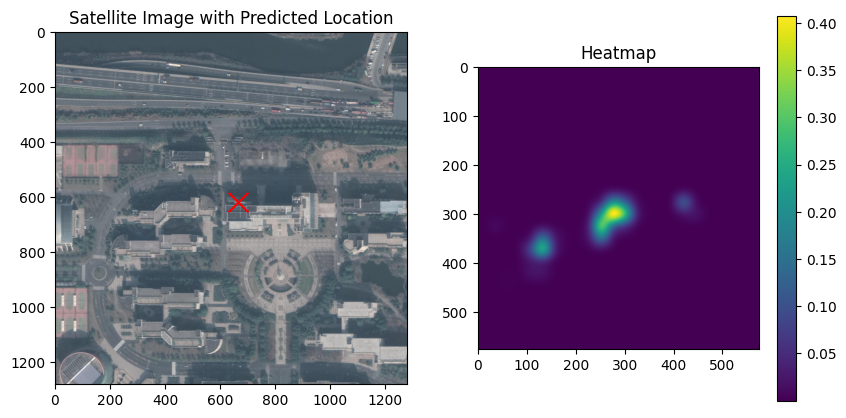

In [245]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(satellite_image)
plt.scatter(x_original, y_original, color='red', s=200, marker='x')
plt.title('Satellite Image with Predicted Location')

plt.subplot(1, 2, 2)
plt.imshow(map)
plt.title('Heatmap')
plt.colorbar()
plt.show()

In [115]:
output[0].shape

torch.Size([1, 1, 576, 576])

In [139]:
def _argmin_abs_coordinate( heatmap: np.ndarray):
    flat_index = np.argmax(heatmap)
    y, x = np.unravel_index(flat_index, heatmap.shape)
    return int(x), int(y)

In [165]:
def weighted_centroid(heatmap: np.ndarray):
    """
    heatmap: 2D массив, значения >= 0 (лучше после sigmoid)
    возвращает (x, y) координаты центра масс в пикселях (float)
    """
    total = heatmap.sum()
    if total == 0:
        # если все нули, вернуть argmax
        y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        return float(x), float(y)
    y_indices, x_indices = np.indices(heatmap.shape)
    weighted_x = (x_indices * heatmap).sum() / total
    weighted_y = (y_indices * heatmap).sum() / total
    return float(weighted_x), float(weighted_y)

In [194]:
from scipy import ndimage

def blob_center(heatmap: np.ndarray, threshold_ratio: float = 0.1):
    # Бинаризация
    binary = heatmap > (threshold_ratio * heatmap.max())
    # Маркировка связных компонент
    labeled, num_features = ndimage.label(binary)
    if num_features == 0:
        return weighted_centroid(heatmap)
    # Для каждой компоненты вычисляем сумму активаций (или просто площадь)
    sums = ndimage.sum(heatmap, labeled, range(1, num_features+1))
    best_idx = np.argmax(sums) + 1   # +1 потому что метки с 1
    # Маска лучшего блоба
    mask = (labeled == best_idx)
    masked = heatmap * mask
    return weighted_centroid(masked)

In [195]:
pixel_x, pixel_y=blob_center(heatmap=response)

In [189]:
response[300][300]

np.float32(0.367455)

In [187]:
pixel_x

269.78643603407284

In [190]:
response = torch.sigmoid(torch.tensor(heatmap)).squeeze().cpu().detach().numpy()  # значения в (0,1)
pos = np.argmax(response)  # теперь это максимум вероятности

In [191]:
coords = np.unravel_index(pos, response.shape)

In [192]:
coords

(np.int64(288), np.int64(264))

In [193]:
response[coords[0]][coords[1]]

np.float32(0.58093655)

In [209]:
import cv2

def smooth_heatmap(heatmap: np.ndarray, sigma: float = 5) -> np.ndarray:
    """Применяет Гауссово размытие к тепловой карте"""
    # sigma = 1...3 даёт хорошее расширение
    ksize = int(2 * round(3 * sigma) + 1)  # нечётный размер
    return cv2.GaussianBlur(heatmap, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)

In [210]:
ans=smooth_heatmap(response)

In [211]:
pos = np.argmax(ans)

In [ ]:
coords = np.unravel_index(pos, .shape)

In [240]:
coords[1]

np.int64(277)

In [216]:
def create_hanning_mask(center_R):
    hann_window = np.outer(  # np.outer 如果a，b是高维数组，函数会自动将其flatten成1维 ，用来求外积
        np.hanning(center_R+2),
        np.hanning(center_R+2))
    hann_window /= hann_window.sum()
    return hann_window[1:-1, 1:-1]

In [244]:
kernel = create_hanning_mask(51)
map = cv2.filter2D(ans, -1, kernel)


In [222]:
map

array([[1.5618880e-07, 1.5617563e-07, 1.5613392e-07, ..., 8.6180457e-08,
        8.6192884e-08, 8.6196806e-08],
       [1.5617492e-07, 1.5616176e-07, 1.5612005e-07, ..., 8.6176257e-08,
        8.6188685e-08, 8.6192600e-08],
       [1.5613095e-07, 1.5611781e-07, 1.5607611e-07, ..., 8.6162942e-08,
        8.6175362e-08, 8.6179277e-08],
       ...,
       [1.4564661e-07, 1.4563589e-07, 1.4560193e-07, ..., 1.6708525e-07,
        1.6713480e-07, 1.6715043e-07],
       [1.4568428e-07, 1.4567354e-07, 1.4563953e-07, ..., 1.6713128e-07,
        1.6718101e-07, 1.6719670e-07],
       [1.4569616e-07, 1.4568542e-07, 1.4565138e-07, ..., 1.6714580e-07,
        1.6719559e-07, 1.6721131e-07]], shape=(576, 576), dtype=float32)

In [232]:
pos = np.argmax(map)  # теперь это максимум вероятности

In [238]:
pos

np.int64(172501)

In [242]:
x_original = (coords[0] / 576) * satellite_image.height
y_original = (coords[1] / 576) * satellite_image.width